In [ ]:
import matplotlib.pyplot as plt
import matplotlib
font = {'family': 'sans-serif', 'weight': 'normal', 'size': 20}
matplotlib.rc('font', **font)

import numpy as np
import os
import pandas as pd
import random
from sklearn import metrics
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import gc

## Loading the Dataset

This dataset is a modified version of the PhysioNet/CinC Challenge data, which were contributed by the Massachusetts General Hospital’s Computational Clinical Neurophysiology Laboratory, and the Clinical Data Animation Laboratory.
***
**Class labels:**
- 0 = Arousal
- 1 = NREM1
- 2 = NREM2
- 3 = NREM3
- 4 = REM
***
**Class descriptions:**

<img src="https://github.com/BeaverWorksMedlytics2020/Data_Public/blob/master/Images/Week2/sleepStagesTable.svg?raw=true">

***
**Physiological signal description:**

O2-M1 - posterior brain activity (electroencephalography)

E1-M2 - left eye activity (electrooculography)

Chin1-Chin2 - chin movement (electromyography)

ABD - abdominal movement (electromyography)

CHEST - chest movement (electromyography)

AIRFLOW - respiratory airflow

ECG - cardiac activity (electrocardiography)
***
Run both cell blocks to get the challenge data.

In [ ]:
# Clone repo and move into data directory (only run this once)
if not os.path.exists("./Data_Public/ChallengeProjects/Week2/"):
    os.system("git clone https://github.com/BeaverWorksMedlytics2020/Data_Public")
os.chdir("./Data_Public/ChallengeProjects/Week2/")


## Loading Data in Memory
Run the cell below to extract the raw training and test data. It may take a minute or two to run through. Here are the variables containing the data you will get:

* **data_train**: np array shape (4000, 12000, 7). Contains 4000 samples (60s each) of 12000 data points (200Hz x 60s), for 7 different signals.
* **labels_train**: np array shape (4000,). Contains ground truth labels for data_train. The order of the labels corresponds to the order of the training data.
* **ID_train**: list of 4000 unique IDs. The order of the IDs corresponds to the order of the training data.
* **data_test**: np array shape (1000, 12000, 7). Contains 1000 samples (60s each) of 12000 data points (200Hz x 60s), for 7 different signals.
* **ID_test**: list of 1000 unique IDs. The order of the IDs corresponds to the order of the training data.

We encourage you to print each of these variables to see what they look like.

In [ ]:
def get_file_locs():
    file_dict = {'training': [], 'test': []}
    for data_type in file_dict:
        for file in os.listdir('./' + data_type):
            file_dict[data_type].append(data_type + '/' + file)
    return file_dict

def get_sample_data(data_type, id_number):
    file = './' + data_type + '/' + str(id_number) + '.xz'
    sample_data = pd.read_pickle('./' + file)
    return sample_data, file.split('/')[2]

file_dict = get_file_locs()
print(f"{len(file_dict['training'])} training samples, {len(file_dict['test'])} test samples")

# Load training data
data_train   = np.zeros((4000, 12000, 7))
labels_train = np.zeros(4000)
ID_train     = []
for i in range(4000):
    sample_data, ID = get_sample_data('training', i)
    data_train[i]   = np.array(list(sample_data['Signal']), dtype=float).reshape(12000, 7)
    labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
    ID_train.append(ID)
    if i % 500 == 0:
        print(f'Loading training sample {i}')

# Load test data
data_test = np.zeros((1000, 12000, 7))
ID_test   = []
for i in range(1000):
    sample_data, ID = get_sample_data('test', i)
    data_test[i]    = np.array(list(sample_data['Signal']), dtype=float).reshape(12000, 7)
    ID_test.append(ID)
    if i % 500 == 0:
        print(f'Loading test sample {i}')

print(f"Train shape: {data_train.shape}")   # (4000, 12000, 7)
print(f"Test shape:  {data_test.shape}")    # (1000, 12000, 7)

4000 training samples, 1000 test samples
Loading training sample 0


/tmp/ipykernel_378/3025138979.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_378/3025138979.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_378/3025138979.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_3

Loading training sample 500


/tmp/ipykernel_378/3025138979.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_378/3025138979.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_378/3025138979.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_3

Loading training sample 1000


...

Loading training sample 3000


/tmp/ipykernel_378/3025138979.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_378/3025138979.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_378/3025138979.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_3

Loading training sample 3500


/tmp/ipykernel_378/3025138979.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_378/3025138979.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_378/3025138979.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_3

Loading test sample 0
Loading test sample 500
Train shape: (4000, 12000, 7)
Test shape:  (1000, 12000, 7)


## Processing labels

In [ ]:
### Create label array for all training samples using categorical datatype ###
train_labels = np.ndarray(shape = (1, 4000))

#set labels to integers first
for i in range(4000):
    train_labels[0][i] = i//800 # This is a way to label each entry (since classes are in order)


# Feature Extraction

## Shuffle and Partition

In [ ]:
shuffled_idx = np.random.permutation(len(data_train))
data_train   = data_train[shuffled_idx]
train_labels = train_labels.squeeze(axis=0)
train_labels = train_labels[shuffled_idx]

val_size      = 1000
mocktest_size = 500

X_test = data_train[0:mocktest_size, :, :]
y_test = train_labels[0:mocktest_size]

X_val  = data_train[mocktest_size:mocktest_size+val_size, :, :]
y_val  = train_labels[mocktest_size:mocktest_size+val_size]

X_tr   = data_train[mocktest_size+val_size:, :, :]
y_tr   = train_labels[mocktest_size+val_size:]

del data_train
del train_labels

print(f"X_tr shape:   {X_tr.shape}")    # (2500, 12000, 7)
print(f"X_val shape:  {X_val.shape}")   # (1000, 12000, 7)
print(f"X_test shape: {X_test.shape}")  # (500, 12000, 7)

X_tr shape:   (2500, 12000, 7)
X_val shape:  (1000, 12000, 7)
X_test shape: (500, 12000, 7)


In [ ]:
# print(X_tr[0, :])
print(y_tr[0])

2.0


In [ ]:
selected_signals = [0, 1, 5, 6]
signal_names     = ['O2-M1', 'E1-M2', 'AIRFLOW', 'ECG']
rate             = 200

def extract_features(X):
    features = []
    for sample in X:
        sample_features = []
        for idx in selected_signals:
            sig      = sample[:, idx]
            fft_vals = np.abs(np.fft.rfft(sig))
            freqs    = np.fft.rfftfreq(len(sig), d=1/rate)
            delta = np.sum(fft_vals[(freqs >= 0.5) & (freqs < 4)])
            theta = np.sum(fft_vals[(freqs >= 4)   & (freqs < 8)])
            alpha = np.sum(fft_vals[(freqs >= 8)   & (freqs < 13)])
            beta  = np.sum(fft_vals[(freqs >= 13)  & (freqs < 30)])
            sample_features.extend([delta, theta, alpha, beta])
        features.append(sample_features)
    return np.array(features)

print("Feature extraction function defined!")

print("Extracting training features...")
X_tr_feat   = extract_features(X_tr)
print(f"X_tr_feat shape: {X_tr_feat.shape}")   # should be (2500, 16)

print("Extracting validation features...")
X_val_feat  = extract_features(X_val)
print(f"X_val_feat shape: {X_val_feat.shape}") # should be (1000, 16)

print("Extracting test features...")
X_test_feat = extract_features(X_test)
print(f"X_test_feat shape: {X_test_feat.shape}") # should be (500, 16)

# Scale features
feat_scaler = StandardScaler()
X_tr_feat   = feat_scaler.fit_transform(X_tr_feat)
X_val_feat  = feat_scaler.transform(X_val_feat)
X_test_feat = feat_scaler.transform(X_test_feat)
print("Done!")

Feature extraction function defined!
Extracting training features...
X_tr_feat shape: (2500, 16)
Extracting validation features...
X_val_feat shape: (1000, 16)
Extracting test features...
X_test_feat shape: (500, 16)
Done!


## Submitting Your Model

After training your classifier, run it on the test data to generate your predictions. Each class for a test sample should have an associated probability (between 0 and 1). Below are the parameters for the prediction format and export:

- Your predictions should be in a pandas dataframe with 5 columns (classes) and 1000 rows (samples). Note that your predictions must follow the original test sample order (0.xz, 1.xz, 2.xz, ...). You only need to worry about this if you shuffled the test samples or stored the samples in an unordered data structure (dictionaries and sets). If this is the case, you should 1) add a separate column in your pandas dataframe with the file number for each sample; 2) sort the dataframe using this column; and 3) drop the column. These steps have been noted in the code below.
- The predictions dataframe should be exported as an .xz file using dataframe.to_pickle() followed by files.download().

Example code of the prediction format and export is presented in the cell block below.

Your model will be evaluated on Area Under the ROC Curve (ROCAUC), Matthews Correlation Coefficient (MCC) and creativity.

If you are finished early, consider trying other ML algorithms and/or implementing multiple feature extraction methods. You can also help other groups if you finish early.

## How Your Model Will Be Evaluated

- **Area Under the ROC Curve (AUCROC)**: The receiver operating characteristic (ROC) curve plots the true positive rate (sensitivity/recall) against the false positive rate (fall-out) at many decision threshold settings. The area under the curve (AUC) measures discrimination, the classifier's ability to correctly identify samples from the "positive" and "negative" cases. Intuitively, AUC is the probability that a randomly chosen "positive" sample will be labeled as "more positive" than a randomly chosen "negative" sample. In the case of a multi-class ROC curve, each class is considered separately before taking the weighted average of all the class results. Simply put, the class under consideration is labeled as "positive" while all other classes are labeled as "negative." Below is the multi-class ROC curve for the example classifier. The AUCROC score should be between 0 and 1, in which 0.5 is random classification and 1 is perfect classification.

<img src="https://github.com/BeaverWorksMedlytics2020/Data_Public/blob/master/Images/Week2/MultiClassRocCurve_exampleClassifier.png?raw=true" width="600" height="500">

- **Matthews Correlation Coefficient (MCC)**: The MCC measures the quality of binary classifications, irrespective of the class sizes. Importantly, it is typically regarded as a balanced measure since it considers all values in the 2x2 contingency table (TP, FP, TN, FN). For this challenge, the binary classes will be "Arousal" (Arousal) and "Nonarousal" (NREM1, NREM2, NREM3, REM). The MCC score should be between -1 and 1, in which 0 is random classification and 1 is perfect classification.

 ![alt text](https://wikimedia.org/api/rest_v1/media/math/render/svg/5caa90fc15105b74b59a30bbc9cc2e5bd43a13b7)

Using these metrics, the example classifier has the following scores on test data:
- AUCROC: 0.727
- MCC: 0.163
- Creativity: ( ͡° ͜ʖ ͡°)

Below is the code used to calculate the AUCROC and MCC metrics when evaluating your classifier.

DECISION TREE


Training Decision Tree...

  Decision Tree
Training Accuracy:  100.00%
Testing Accuracy:   53.60%
              precision    recall  f1-score   support

     Arousal       0.41      0.51      0.45        88
       NREM1       0.53      0.41      0.46        98
       NREM2       0.45      0.39      0.42       117
       NREM3       0.72      0.80      0.76        94
         REM       0.58      0.60      0.59       103

    accuracy                           0.54       500
   macro avg       0.54      0.54      0.54       500
weighted avg       0.53      0.54      0.53       500



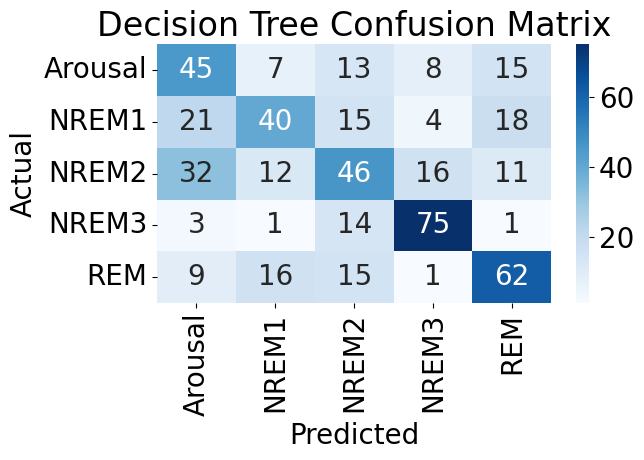

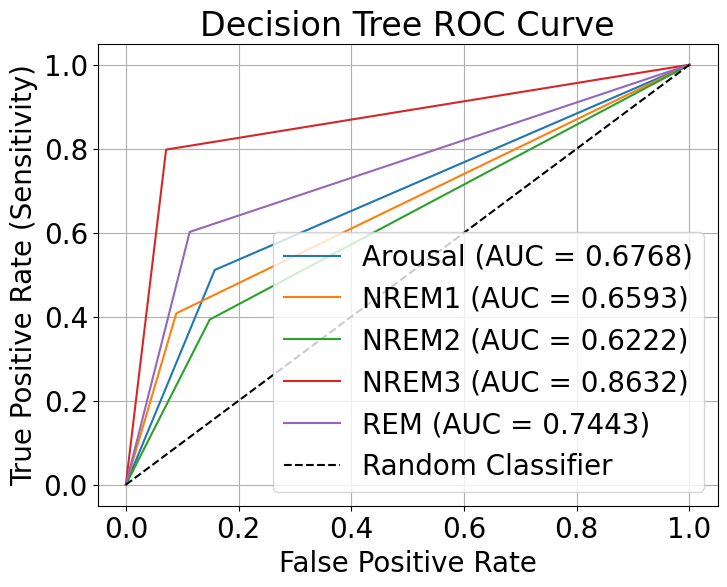

Aggregate ROC AUC Score: 0.7132
Matthews Correlation Coefficient: 0.3251


/tmp/ipykernel_378/205741202.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Score', y='Feature', palette='Blues_r')


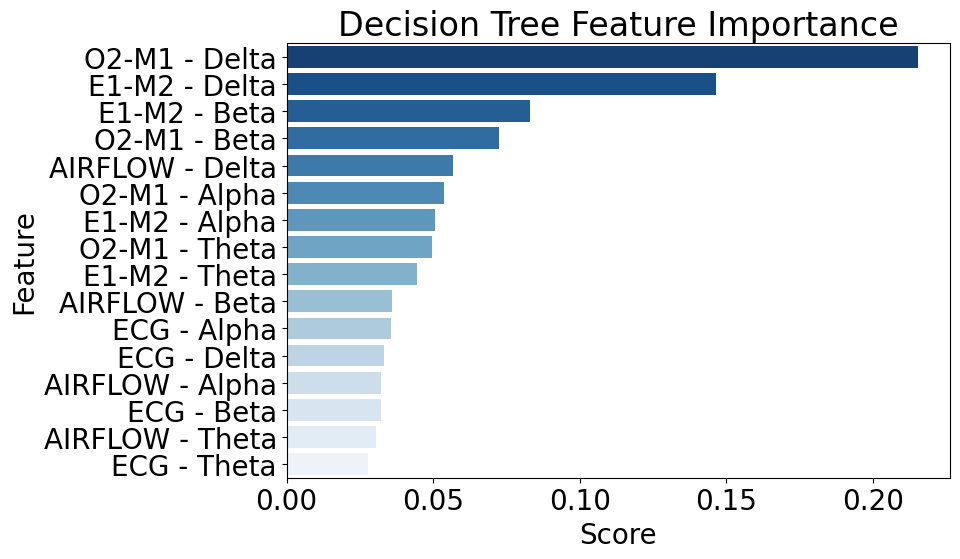

        Feature    Score
  O2-M1 - Delta 0.215558
  E1-M2 - Delta 0.146489
   E1-M2 - Beta 0.082985
   O2-M1 - Beta 0.072512
AIRFLOW - Delta 0.056646
  O2-M1 - Alpha 0.053827
  E1-M2 - Alpha 0.050642
  O2-M1 - Theta 0.049474
  E1-M2 - Theta 0.044375
 AIRFLOW - Beta 0.035775
    ECG - Alpha 0.035608
    ECG - Delta 0.033051
AIRFLOW - Alpha 0.032335
     ECG - Beta 0.032321
AIRFLOW - Theta 0.030580
    ECG - Theta 0.027822


In [ ]:
stage_dict = {0:'Arousal', 1:'NREM1', 2:'NREM2', 3:'NREM3', 4:'REM'}
stages     = list(stage_dict.values())

def evaluate_model(name, model, X_tr_feat, y_tr, X_test_feat, y_test):
    train_acc   = accuracy_score(y_tr,    model.predict(X_tr_feat))
    test_acc    = accuracy_score(y_test,  model.predict(X_test_feat))
    y_pred      = model.predict(X_test_feat)
    y_pred_prob = model.predict_proba(X_test_feat)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Training Accuracy:  {train_acc*100:.2f}%")
    print(f"Testing Accuracy:   {test_acc*100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=stages))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=stages, yticklabels=stages)
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

    # ROC Curve
    y_test_onehot = pd.DataFrame(np.eye(5)[y_test.astype(int)])
    fpr, tpr, roc_auc_scores = {}, {}, {}
    plt.figure(figsize=(8, 6))
    for i in range(5):
        fpr[i], tpr[i], _    = roc_curve(y_test_onehot.iloc[:, i], y_pred_prob[:, i])
        roc_auc_scores[i]    = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], label=f'{stages[i]} (AUC = {roc_auc_scores[i]:.4f})')
    roc_auc_agg = np.mean(list(roc_auc_scores.values()))
    plt.plot([0,1],[0,1],'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title(f'{name} ROC Curve')
    plt.legend(loc='lower right'); plt.grid(True); plt.show()
    print(f"Aggregate ROC AUC Score: {roc_auc_agg:.4f}")

    # MCC
    y_true_mcc = [1 if y == 0 else -1 for y in y_test]
    y_pred_mcc = [1 if y == 0 else -1 for y in y_pred]
    mcc = metrics.matthews_corrcoef(y_true_mcc, y_pred_mcc)
    print(f"Matthews Correlation Coefficient: {mcc:.4f}")

    return roc_auc_agg, mcc

print("Training Decision Tree...")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_tr_feat, y_tr)
dt_auc, dt_mcc = evaluate_model("Decision Tree", dt, X_tr_feat, y_tr, X_test_feat, y_test)

# Feature Importance
feature_names = [f'{sig} - {band}' for sig in signal_names
                 for band in ['Delta','Theta','Alpha','Beta']]
importances = pd.DataFrame({
    'Feature': feature_names,
    'Score':   dt.feature_importances_
}).sort_values('Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Score', y='Feature', palette='Blues_r')
plt.title('Decision Tree Feature Importance')
plt.tight_layout(); plt.show()
print(importances.to_string(index=False))

SUPPORT VECTOR MODEL

Training SVM (may take a few minutes)...

  SVM
Training Accuracy:  62.40%
Testing Accuracy:   56.80%
              precision    recall  f1-score   support

     Arousal       0.42      0.48      0.45        88
       NREM1       0.51      0.58      0.55        98
       NREM2       0.53      0.35      0.42       117
       NREM3       0.72      0.89      0.80        94
         REM       0.62      0.58      0.60       103

    accuracy                           0.57       500
   macro avg       0.56      0.58      0.56       500
weighted avg       0.56      0.57      0.56       500



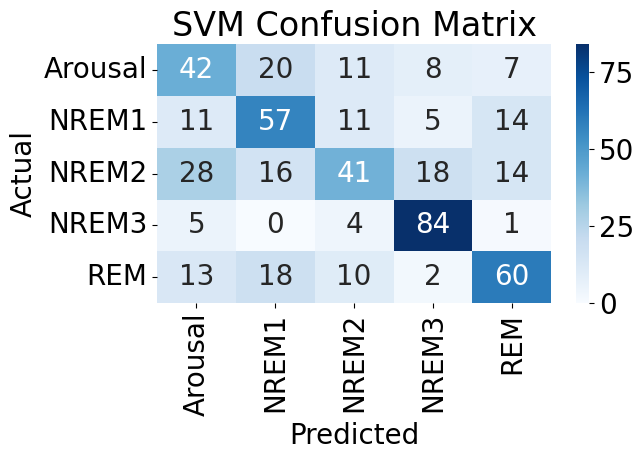

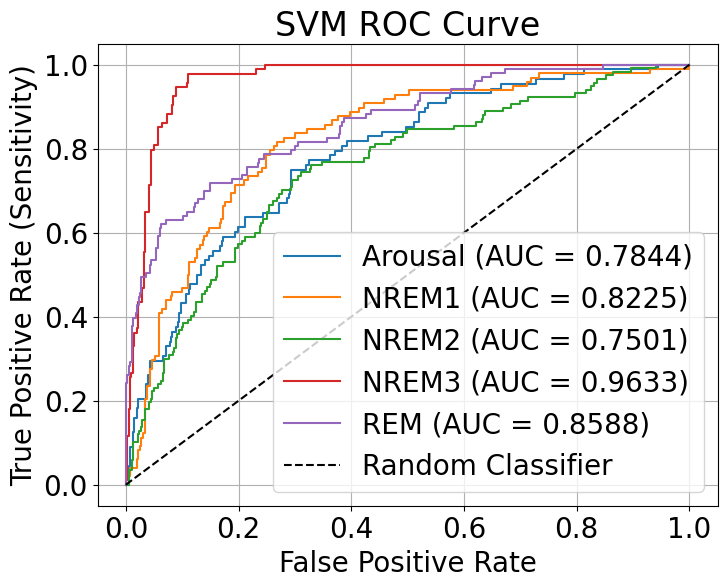

Aggregate ROC AUC Score: 0.8358
Matthews Correlation Coefficient: 0.3239

  MODEL COMPARISON
Model                ROC AUC         MCC
Decision Tree        0.7132          0.3251
SVM                  0.8358          0.3239


In [ ]:
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_tr_feat, y_tr)
svm_auc, svm_mcc = evaluate_model("SVM", svm, X_tr_feat, y_tr, X_test_feat, y_test)

print("\n" + "="*50)
print("  MODEL COMPARISON")
print("="*50)
print(f"{'Model':<20} {'ROC AUC':<15} {'MCC'}")
print(f"{'Decision Tree':<20} {dt_auc:<15.4f} {dt_mcc:.4f}")
print(f"{'SVM':<20} {svm_auc:<15.4f} {svm_mcc:.4f}")